# Solution 2.1: Loading Data & First Diagnostics (Angola IEA)

This notebook uses `IEA_2025_IV_TRIM_IND.sav`, the individual file of the
Inquerito ao Emprego em Angola (IEA), 4th quarter 2025, published by INE Angola.

It is a real SPSS export: 53,353 people, 206 columns, all variable and value
labels in Portuguese.

You will practice:
- Loading an SPSS file with `pd.read_spss()`
- Deciding whether to apply the file's value labels, and seeing what that costs
- Reading the codebook that ships inside the file
- Loading only the columns you need with `usecols`
- Running structural diagnostics with `info()`, `describe()` and `value_counts()`
- Spotting sentinel codes and empty columns before any cleaning

> **Pipeline:** this notebook only reads `0_raw/`. It writes nothing.

### Path Setup (run first)

> Use `os.path.join` for path construction.
> Required base path: `DATA_RAW_DIR = '../../data/0_raw/angola/employment_survey'`.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

DATA_RAW_DIR = '../../data/0_raw/angola/employment_survey'
RAW_FILE = 'IEA_2025_IV_TRIM_IND.sav'
raw_path = os.path.join(DATA_RAW_DIR, RAW_FILE)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Data path:', raw_path)
print('Exists?:', os.path.exists(raw_path))

Data path: ../../data/0_raw/angola/employment_survey/IEA_2025_IV_TRIM_IND.sav
Exists?: True


---

## Task 1: Load the file and take a first look

`pd.read_spss()` reads SPSS `.sav` files. By default it applies the value labels
stored in the file, so coded variables come back as readable text.

In [2]:
df_labelled = pd.read_spss(raw_path)

print('Shape:', df_labelled.shape)
df_labelled[['PROV', 'AREA_RESID', 'DEM_SEX', 'DEM_AGE']].head()

Shape: (53353, 206)


,PROV,AREA_RESID,DEM_SEX,DEM_AGE
0,Namibe,Urbana,Feminino,45.00
1,Cuando,Rural,Masculino,7.00
2,Cuanza-Sul,Rural,Masculino,15.00
3,Cuanza-Sul,Rural,Masculino,30.00
4,Cuanza-Sul,Rural,Masculino,37.00


In [3]:
df_labelled[['PROV', 'AREA_RESID', 'DEM_SEX']].tail()

,PROV,AREA_RESID,DEM_SEX
53348,Cunene,Rural,Masculino
53349,Cunene,Rural,Masculino
53350,Cunene,Rural,Masculino
53351,Cunene,Rural,Masculino
53352,Cunene,Rural,Masculino


In [4]:
df_labelled[['PROV', 'AREA_RESID', 'DEM_SEX', 'DEM_AGE']].sample(5, random_state=0)

,PROV,AREA_RESID,DEM_SEX,DEM_AGE
19979,Uíge,Rural,Masculino,18.00
35163,Malanje,Rural,Feminino,6.00
52182,Icolo e Bengo,Urbana,Feminino,15.00
23162,Icolo e Bengo,Urbana,Feminino,47.00
27053,Luanda,Urbana,Feminino,6.00


**Answers:**

- The file holds 53,353 rows and 206 columns, one row per person interviewed.
- `PROV`, `AREA_RESID` and `DEM_SEX` arrive as readable Portuguese text
  (`Luanda`, `Urbana`, `Feminino`) rather than the numeric codes actually stored
  in the file, because `pd.read_spss` applies value labels by default.
- 206 columns is far more than any single analysis needs, which is what Task 4
  addresses.

---

## Task 2: The cost of applying value labels

Value labels are convenient, but they are applied to **every** labelled variable,
including ones where the label is a sentinel rather than a category. Reload with
`convert_categoricals=False` and compare the dtypes.

In [5]:
df_raw = pd.read_spss(raw_path, convert_categoricals=False)

comparison = pd.DataFrame({
    'labelled': df_labelled[['PROV', 'DEM_SEX', 'MJT_SYR', 'DEM_AGE']].dtypes,
    'raw_codes': df_raw[['PROV', 'DEM_SEX', 'MJT_SYR', 'DEM_AGE']].dtypes,
})
comparison

,labelled,raw_codes
PROV,category,float64
DEM_SEX,category,float64
MJT_SYR,category,float64
DEM_AGE,float64,float64


In [6]:
# MJT_SYR is the year the person started their main job.
print('Labelled, first 5 values:')
print(df_labelled['MJT_SYR'].head().tolist())
print()
print('Raw codes, describe:')
print(df_raw['MJT_SYR'].describe())

Labelled, first 5 values:
[2022.0, nan, nan, nan, 1998.0]

Raw codes, describe:
count   11,637.00
mean     3,164.62
std      2,799.78
min      1,965.00
25%      2,016.00
50%      2,021.00
75%      2,025.00
max      9,997.00
Name: MJT_SYR, dtype: float64


**Answers:**

- `MJT_SYR` is a **year**, but the labelled load returns it as `category`. That
  happens because the value `9997` carries the label `NAO SABE`, so pandas treats
  the whole column as categorical. A year you cannot subtract is useless.
- The raw load returns `float64` and `describe()` immediately exposes the damage:
  a mean of 3164.6 against a real range of 1965 to 2025.
- The rest of this series uses `convert_categoricals=False`, so the codes stay
  numeric and we decode them ourselves in 2.4. That is the same choice the Stata
  callout in the lesson recommends with `convert_categoricals=False`.

---

## Task 3: Read the codebook that ships inside the file

An SPSS file carries its own documentation: a label for every variable, and a
label for every coded value. The lesson shows this for Stata with
`variable_labels()`. For SPSS the equivalent lives in `pyreadstat`, and it can be
read **without loading the data**.

> This is the only cell in the whole series that imports `pyreadstat` directly.

In [7]:
import pyreadstat

_, meta = pyreadstat.read_sav(raw_path, metadataonly=True)

for name in ['PROV', 'AREA_RESID', 'DEM_SEX', 'DEM_AGE', 'WKT_USHRSTOT', 'MJT_SYR']:
    print(f'{name:15s} {meta.column_names_to_labels[name]}')

PROV            G.01 Provincia
AREA_RESID      G.05_Área de Residência
DEM_SEX         S02_01 Qual é o sexo do(a) nome
DEM_AGE         S02_03 Qual é a idade do(a) nome
WKT_USHRSTOT    S05_69 Quantas horas o(a) nome geralmente trabalha por semana no total?
MJT_SYR         S05_15 Em que ano o(a) nome começou a trabalhar no seu emprego principal?


In [8]:
# Value labels: the code to text mapping behind each categorical variable
label_set = meta.variable_to_label['PROV']
print('PROV has', len(meta.value_labels[label_set]), 'provinces')
print(meta.value_labels[label_set])

PROV has 21 provinces
{10.0: 'Cabinda', 11.0: 'Zaire', 12.0: 'Uíge', 13.0: 'Bengo', 14.0: 'Luanda', 15.0: 'Cuanza-Norte', 16.0: 'Cuanza-Sul', 17.0: 'Malanje', 18.0: 'Lunda-Norte', 19.0: 'Lunda-Sul', 20.0: 'Moxico', 21.0: 'Bié', 22.0: 'Huambo', 23.0: 'Benguela', 24.0: 'Namibe', 25.0: 'Huila', 26.0: 'Cunene', 27.0: 'Cubango', 28.0: 'Icolo e Bengo', 29.0: 'Moxico Leste', 30.0: 'Cuando'}


**Answers:**

- Without the codebook, `WKT_USHRSTOT` is meaningless. With it, we know it is
  "Quantas horas o(a) nome geralmente trabalha por semana no total?", the usual
  weekly hours across all jobs.
- `PROV` maps 21 codes, 10 to 30, onto province names. Note that Angola created
  three new provinces in 2024: Icolo e Bengo (28), Moxico Leste (29) and Cuando
  (30). Any lookup table built before 2024 will be missing them, which is exactly
  the merge problem waiting in 2.5.
- Reading metadata only is fast because no data is loaded, so it is the cheapest
  possible first step with an unfamiliar file.

---

## Task 4: Load only the columns you need with `usecols`

206 columns is more than this analysis needs. `usecols` tells the reader to skip
the rest entirely, so they never enter memory.

The 29 columns below carry the survey's demographic core, its labour module, the
interview date, and the survey weight.

In [9]:
SPSS_COLS = [
    'NIDF', 'PPNO', 'G_06_ID_IEA', 'PROV', 'AREA_RESID', 'G_15_TRIMESTRE',
    'DEM_REL', 'DEM_SEX', 'DEM_AGE', 'DEM_MRT', 'DEM_EDL', 'S03_01',
    'ATW_PAY', 'ATW_PFT', 'ATW_FAM', 'ABS_JOB',
    'SRH_JOB', 'SRH_BUS', 'SRH_AVN', 'SRH_AVL', 'SRH_DES',
    'WKT_USHRSTOT', 'WKT_ACHRSTOT', 'MJT_SYR', 'MJJ_EMP_REL', 'GHVEDT',
    'POND_IEA_IV_TRIM_2025_IND', 'G_12', 'G_13',
]

df = pd.read_spss(raw_path, usecols=SPSS_COLS, convert_categoricals=False)
print('Full file: ', df_raw.shape)
print('Subset:    ', df.shape)
df.head()

Full file:  (53353, 206)
Subset:     (53353, 29)


,NIDF,G_06_ID_IEA,PROV,DEM_REL,AREA_RESID,G_12,G_13,G_15_TRIMESTRE,DEM_SEX,PPNO,...,MJT_SYR,WKT_USHRSTOT,WKT_ACHRSTOT,SRH_JOB,SRH_BUS,SRH_DES,SRH_AVN,SRH_AVL,GHVEDT,POND_IEA_IV_TRIM_2025_IND
0,"9,250,068.00",925.00,24.00,2.00,1.00,NaN,NaN,4.00,2.00,2.00,...,"2,022.00",66.00,66.00,NaN,NaN,NaN,NaN,NaN,"20,251,204.00",322.02
1,"12,870,026.00","1,287.00",30.00,5.00,2.00,NaN,NaN,4.00,1.00,9.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,171.30
2,"4,600,048.00",460.00,16.00,3.00,2.00,NaN,NaN,4.00,1.00,2.00,...,NaN,NaN,NaN,2.00,2.00,1.00,1.00,NaN,"20,251,212.00","1,010.98"
3,"4,600,023.00",460.00,16.00,1.00,2.00,NaN,NaN,4.00,1.00,1.00,...,NaN,NaN,NaN,2.00,2.00,2.00,NaN,NaN,"20,251,212.00",999.80
4,"4,790,052.00",479.00,16.00,1.00,2.00,NaN,NaN,4.00,1.00,1.00,...,"1,998.00",30.00,30.00,NaN,NaN,NaN,NaN,NaN,"20,251,216.00","1,011.64"


In [10]:
full_mb = df_raw.memory_usage(deep=True).sum() / 1e6
subset_mb = df.memory_usage(deep=True).sum() / 1e6
print(f'Memory full:   {full_mb:8.2f} MB')
print(f'Memory subset: {subset_mb:8.2f} MB')
print(f'Saved:         {(1 - subset_mb / full_mb) * 100:8.1f}%')

Memory full:     169.84 MB
Memory subset:    12.38 MB
Saved:             92.7%


**Answers:**

- The subset keeps all 53,353 rows but only 29 of 206 columns, cutting memory by
  roughly 90%.
- `usecols` skips columns at read time. Loading everything and then selecting
  with `df[COLS]` produces the same table but pays the full memory and time cost
  first, which matters when the file is larger than this one.
- A misspelled name in `SPSS_COLS` raises an error rather than being ignored,
  which is what you want.

---

## Task 5: Structural health check with `info()`

`df.info()` is the first diagnostic. Read the Non-Null Count column carefully:
it is where empty columns and skip patterns show up.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53353 entries, 0 to 53352
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   NIDF                       53353 non-null  float64
 1   G_06_ID_IEA                53353 non-null  float64
 2   PROV                       53353 non-null  float64
 3   DEM_REL                    53352 non-null  float64
 4   AREA_RESID                 53353 non-null  float64
 5   G_12                       0 non-null      float64
 6   G_13                       0 non-null      float64
 7   G_15_TRIMESTRE             53353 non-null  float64
 8   DEM_SEX                    53353 non-null  float64
 9   PPNO                       53353 non-null  float64
 10  DEM_AGE                    53353 non-null  float64
 11  DEM_MRT                    32861 non-null  float64
 12  S03_01                     45371 non-null  float64
 13  DEM_EDL                    23168 non-null  flo

In [12]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(1),
}).sort_values('pct_missing', ascending=False)
missing

,n_missing,pct_missing
G_12,53353,100.00
G_13,53353,100.00
SRH_AVL,52539,98.50
SRH_AVN,43049,80.70
ABS_JOB,42761,80.10
MJJ_EMP_REL,41716,78.20
WKT_USHRSTOT,41716,78.20
MJT_SYR,41716,78.20
WKT_ACHRSTOT,41716,78.20
ATW_FAM,39090,73.30


**Answers:**

- `G_12` and `G_13` are **100% missing**: 53,353 nulls out of 53,353 rows. They
  should hold household size and the number of adults, so they look useful in a
  column list and are worth nothing in practice. They get dropped in 2.3.
- The labour module columns (`MJT_SYR`, `WKT_USHRSTOT`, `MJJ_EMP_REL`) are around
  78% missing, and `SRH_AVL` is 98.5% missing. This is **not** damage. Those
  questions are only asked of people the questionnaire routes to them. Missing by
  design and missing by error need completely different treatment, which is the
  main lesson of 2.3.
- Everything is `float64`, including the identifiers `NIDF` and `PPNO` and the
  date `GHVEDT`. All three are wrong types, fixed in 2.2.

---

## Task 6: Summary statistics with `describe()`

`describe()` exposes impossible values. Look hard at every `min` and `max`.

In [13]:
df[['DEM_AGE', 'WKT_USHRSTOT', 'WKT_ACHRSTOT', 'MJT_SYR', 'GHVEDT']].describe().T

,count,mean,std,min,25%,50%,75%,max
DEM_AGE,"53,353.00",21.89,18.10,0.00,8.00,17.00,32.00,120.00
WKT_USHRSTOT,"11,637.00",46.12,24.11,1.00,35.00,48.00,60.00,997.00
WKT_ACHRSTOT,"11,637.00",45.70,32.83,0.00,35.00,48.00,60.00,997.00
MJT_SYR,"11,637.00","3,164.62","2,799.78","1,965.00","2,016.00","2,021.00","2,025.00","9,997.00"
GHVEDT,"29,682.00","20,251,351.26","1,210.91","20,241,110.00","20,251,127.00","20,251,208.00","20,251,218.00","20,260,128.00"


In [14]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
NIDF,"53,353.00","6,623,692.70","3,718,875.63","10,005.00","3,440,107.00","6,690,016.00","9,810,016.00","13,080,051.00"
G_06_ID_IEA,"53,353.00",662.36,371.89,1.00,344.00,669.00,981.00,"1,308.00"
PROV,"53,353.00",19.76,5.90,10.00,14.00,20.00,25.00,30.00
DEM_REL,"53,352.00",2.79,1.71,1.00,2.00,3.00,3.00,11.00
AREA_RESID,"53,353.00",1.36,0.48,1.00,1.00,1.00,2.00,2.00
G_12,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G_13,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G_15_TRIMESTRE,"53,353.00",4.00,0.00,4.00,4.00,4.00,4.00,4.00
DEM_SEX,"53,353.00",1.52,0.50,1.00,1.00,2.00,2.00,2.00
PPNO,"53,353.00",3.31,2.18,1.00,2.00,3.00,5.00,20.00


**Answers:**

- `MJT_SYR` has a mean of 3164.6 and a max of 9997. `9997` is the "NAO SABE"
  sentinel and there are 1,673 of them, dragging the mean nearly 1,150 years into
  the future.
- `WKT_USHRSTOT` maxes at 997, the same sentinel pattern. Its real maximum is 120
  hours a week, which is itself implausible and gets a validation rule in 2.3.
- `DEM_AGE` runs from 0 to 120. Age 0 is legitimate: 1,532 infants. Age 120 is
  not.
- `GHVEDT` has a mean around 20,251,000, which is nonsense as a number because it
  is really the date 2025-12-04 stored as the digits `20251204`.

---

## Task 7: Explore categories with `value_counts()`

`value_counts()` is the fastest way to see what is actually in a coded column.
Always pass `dropna=False` so the gaps are counted too.

In [15]:
print(df['PROV'].value_counts(dropna=False).sort_index())

PROV
10.00    2305
11.00    1906
12.00    3029
13.00    2235
14.00    4424
15.00    2676
16.00    2530
17.00    2332
18.00    2067
19.00    2914
20.00    1782
21.00    2422
22.00    2797
23.00    2476
24.00    3108
25.00    2837
26.00    2694
27.00    2309
28.00    2889
29.00    2123
30.00    1498
Name: count, dtype: int64


In [16]:
print(df['AREA_RESID'].value_counts(dropna=False))
print()
print(df['DEM_SEX'].value_counts(dropna=False))
print()
print(df['DEM_EDL'].value_counts(dropna=False).sort_index())

AREA_RESID
1.00    34173
2.00    19180
Name: count, dtype: int64

DEM_SEX
2.00    27752
1.00    25601
Name: count, dtype: int64

DEM_EDL
1.00    12527
2.00     5162
3.00     4489
4.00       61
5.00      782
6.00       13
7.00        1
9.00      133
NaN     30185
Name: count, dtype: int64


In [17]:
print('Distinct households:', df['NIDF'].nunique())
print('Rows per household, describe:')
print(df['NIDF'].value_counts().describe())

Distinct households: 13036
Rows per household, describe:
count   13,036.00
mean         4.09
std          2.47
min          1.00
25%          2.00
50%          4.00
75%          6.00
max         20.00
Name: count, dtype: float64


**Answers:**

- All 21 province codes appear, from 10 to 30, with Luanda (14) the largest at
  4,424 people.
- `AREA_RESID` splits 34,173 urban and 19,180 rural. `DEM_SEX` splits 25,601 male
  and 27,752 female.
- `DEM_EDL` is 56.6% missing and its codes jump from 7 to 9, with no 8. Reading
  the codebook explains it: 9 means "Nenhum nivel", no level, so it is not an
  ordinal step above 7.
- There are 13,036 households across 53,353 people, a mean of 4.09 people each.
  Remember this number: 2.4 derives household size a different way and gets 5.58,
  for a reason worth understanding.

---

## Task 8: A quick visual sweep

Histograms of every numeric column at once are a fast way to spot sentinels: they
appear as a lonely spike far to the right of everything else.

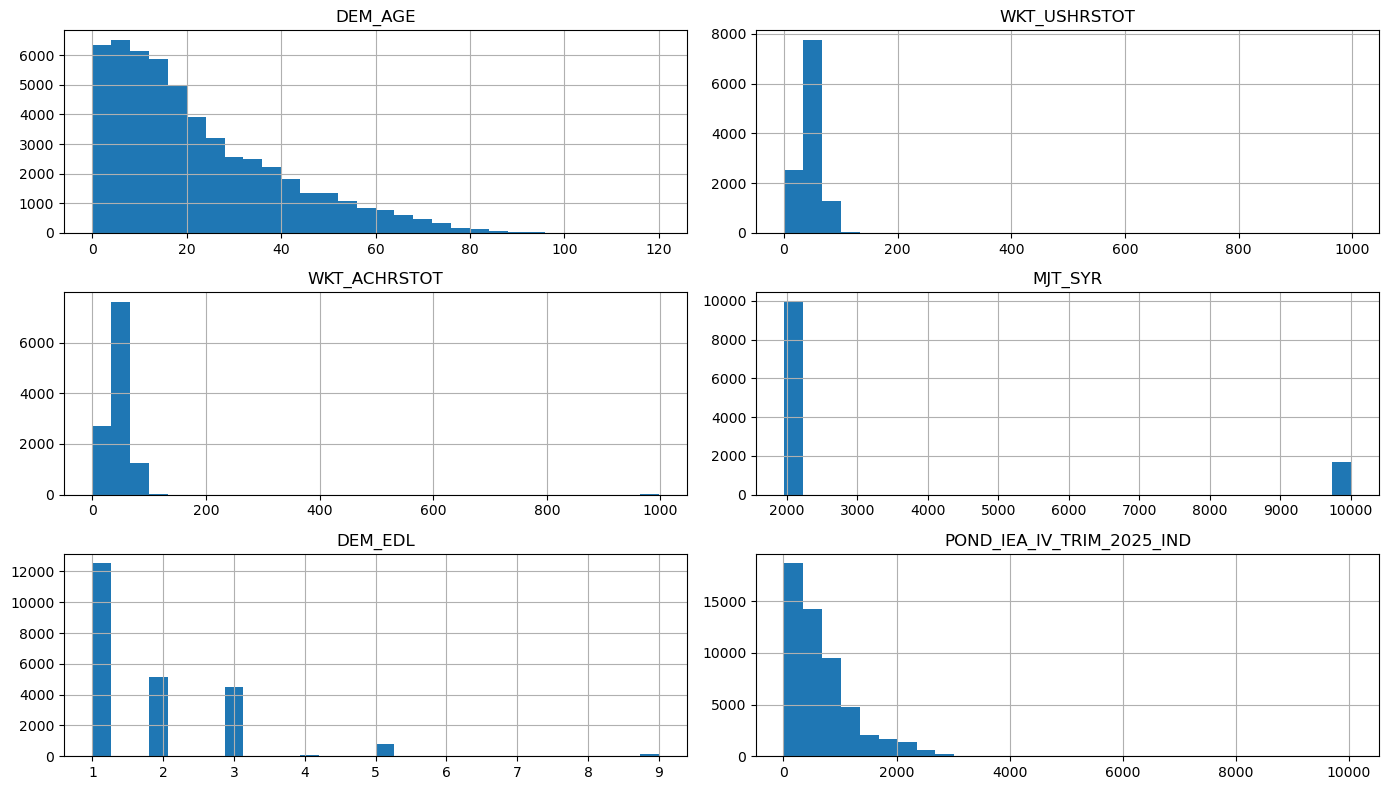

In [18]:
df[['DEM_AGE', 'WKT_USHRSTOT', 'WKT_ACHRSTOT', 'MJT_SYR',
    'DEM_EDL', 'POND_IEA_IV_TRIM_2025_IND']].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

**Answers:**

- `MJT_SYR` and `WKT_USHRSTOT` both show a tiny bar at the far right, isolated
  from the rest of the distribution. That shape is the visual signature of a
  sentinel code.
- `DEM_AGE` is heavily skewed towards the young, which is expected for Angola:
  the median age in this sample is 17.
- None of these columns is ready for analysis yet. 2.2 fixes the types and 2.3
  removes the sentinels.